C:\Users\HANIN\AppData\Local\Temp\ipykernel_26224\1620794951.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)


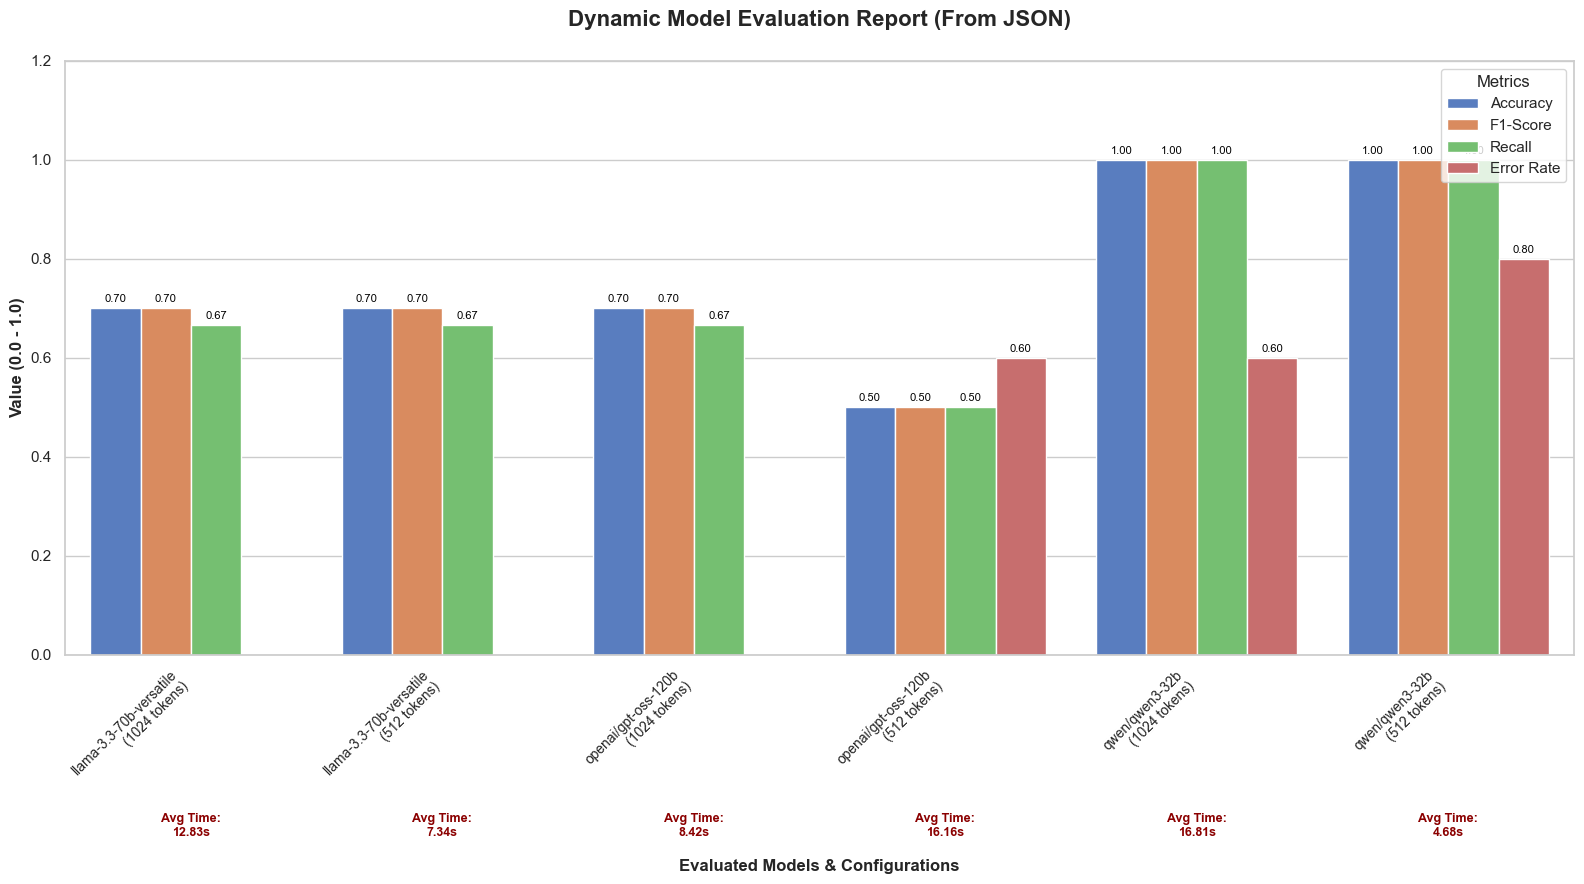

In [1]:
import json
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

JSON_FILE_NAME = "json_results/experience_evidence_finder.json"  

if not os.path.exists(JSON_FILE_NAME):
    raise FileNotFoundError(f"Result file {JSON_FILE_NAME} not found.")

with open(JSON_FILE_NAME, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

parsed_runs = []
for run in raw_data:
    model_name = run.get("model_name", "Unknown").split(":")[-1] 
    max_tokens = run.get("model_kwargs", {}).get("max_tokens", 0)
    results = run.get("results", {})
    
    model_tag = f"{model_name}\n({max_tokens} tokens)"
    
    parsed_runs.append({
        "Model": model_tag,
        "Accuracy": results.get("classification_accuracy", 0.0),
        "F1-Score": results.get("classification_f1_score", 0.0),
        "Recall": results.get("classification_recall", 0.0),
        "Error Rate": results.get("error_rate", 0.0),
        "Time (s)": results.get("agent_invokation_time", 0.0)
    })

df = pd.DataFrame(parsed_runs)

df_grouped = df.groupby("Model", as_index=False).mean()

df_melted = pd.melt(
    df_grouped, 
    id_vars=["Model", "Time (s)"], 
    value_vars=["Accuracy", "F1-Score", "Recall", "Error Rate"],
    var_name="Metric", 
    value_name="Score"
)

plt.figure(figsize=(16, 9))
sns.set_theme(style="whitegrid")

ax = sns.barplot(x="Model", y="Score", hue="Metric", data=df_melted, palette="muted")

for p in ax.patches:
    height = p.get_height()
    if height > 0.01:
        ax.annotate(f'{height:.2f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=8, color='black',
                    xytext=(0, 3),
                    textcoords='offset points')

plt.title("Dynamic Model Evaluation Report (From JSON)", fontsize=16, fontweight='bold', pad=25)
plt.ylabel("Value (0.0 - 1.0)", fontsize=12, fontweight='bold')
plt.ylim(0, 1.2) 
plt.legend(title="Metrics", loc="upper right", frameon=True)

plt.xlabel("Evaluated Models & Configurations", fontsize=12, fontweight='bold', labelpad=50)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)

for i, row in df_grouped.iterrows():
    ax.text(i, -0.32, f"Avg Time:\n{row['Time (s)']:.2f}s", 
            ha='center', va='top', fontsize=9, color='darkred', fontweight='bold')

plt.subplots_adjust(bottom=0.28)
plt.tight_layout()
plt.show()

C:\Users\HANIN\AppData\Local\Temp\ipykernel_15860\3985244357.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)


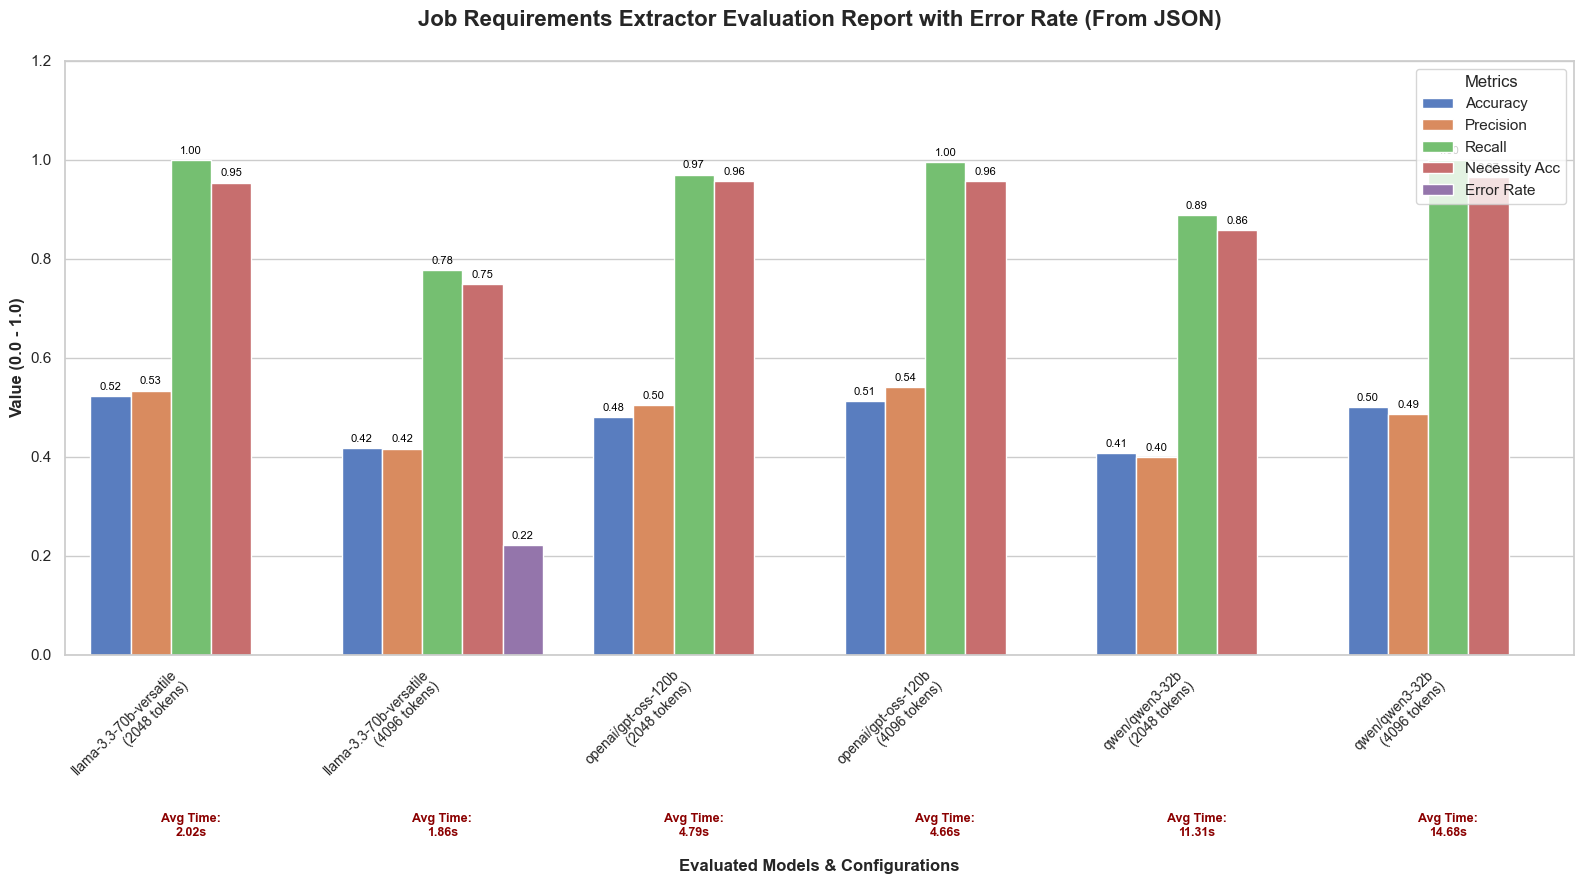

In [ ]:
import json
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

JSON_FILE_NAME = "json_results/job_requirements_extractor.json"  

if not os.path.exists(JSON_FILE_NAME):
    raise FileNotFoundError(f"Result file {JSON_FILE_NAME} not found.")

with open(JSON_FILE_NAME, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

parsed_runs = []
for run in raw_data:
    model_name = run.get("model_name", "Unknown").split(":")[-1] 
    max_tokens = run.get("model_kwargs", {}).get("max_tokens", 0)
    results = run.get("results", {})
    
    model_tag = f"{model_name}\n({max_tokens} tokens)"
    
    accuracy = results.get("requirements_extraction_accuracy", 0.0)
    precision = results.get("requirements_extraction_precision", 0.0)
    calculated_error = 1.0 if (accuracy == 0.0 and precision == 0.0) else 0.0
    
    parsed_runs.append({
        "Model": model_tag,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": results.get("requirements_extraction_recall", 0.0),
        "Necessity Acc": results.get("requirements_necessity_accuracy", 0.0),
        "Error Rate": calculated_error,
        "Time (s)": results.get("agent_invokation_time", 0.0)
    })

df = pd.DataFrame(parsed_runs)

df_grouped = df.groupby("Model", as_index=False).mean()

df_melted = pd.melt(
    df_grouped, 
    id_vars=["Model", "Time (s)"], 
    value_vars=["Accuracy", "Precision", "Recall", "Necessity Acc", "Error Rate"],
    var_name="Metric", 
    value_name="Score"
)

plt.figure(figsize=(16, 9))
sns.set_theme(style="whitegrid")

ax = sns.barplot(x="Model", y="Score", hue="Metric", data=df_melted, palette="muted")

for p in ax.patches:
    height = p.get_height()
    if height > 0.01:
        ax.annotate(f'{height:.2f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=8, color='black',
                    xytext=(0, 3),
                    textcoords='offset points')

plt.title("Job Requirements Extractor Evaluation Report with Error Rate (From JSON)", fontsize=16, fontweight='bold', pad=25)
plt.ylabel("Value (0.0 - 1.0)", fontsize=12, fontweight='bold')
plt.ylim(0, 1.2) 
plt.legend(title="Metrics", loc="upper right", frameon=True)

plt.xlabel("Evaluated Models & Configurations", fontsize=12, fontweight='bold', labelpad=50)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)

for i, row in df_grouped.iterrows():
    ax.text(i, -0.32, f"Avg Time:\n{row['Time (s)']:.2f}s", 
            ha='center', va='top', fontsize=9, color='darkred', fontweight='bold')

plt.subplots_adjust(bottom=0.28)
plt.tight_layout()
plt.show()

C:\Users\HANIN\AppData\Local\Temp\ipykernel_15860\1259896914.py:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)


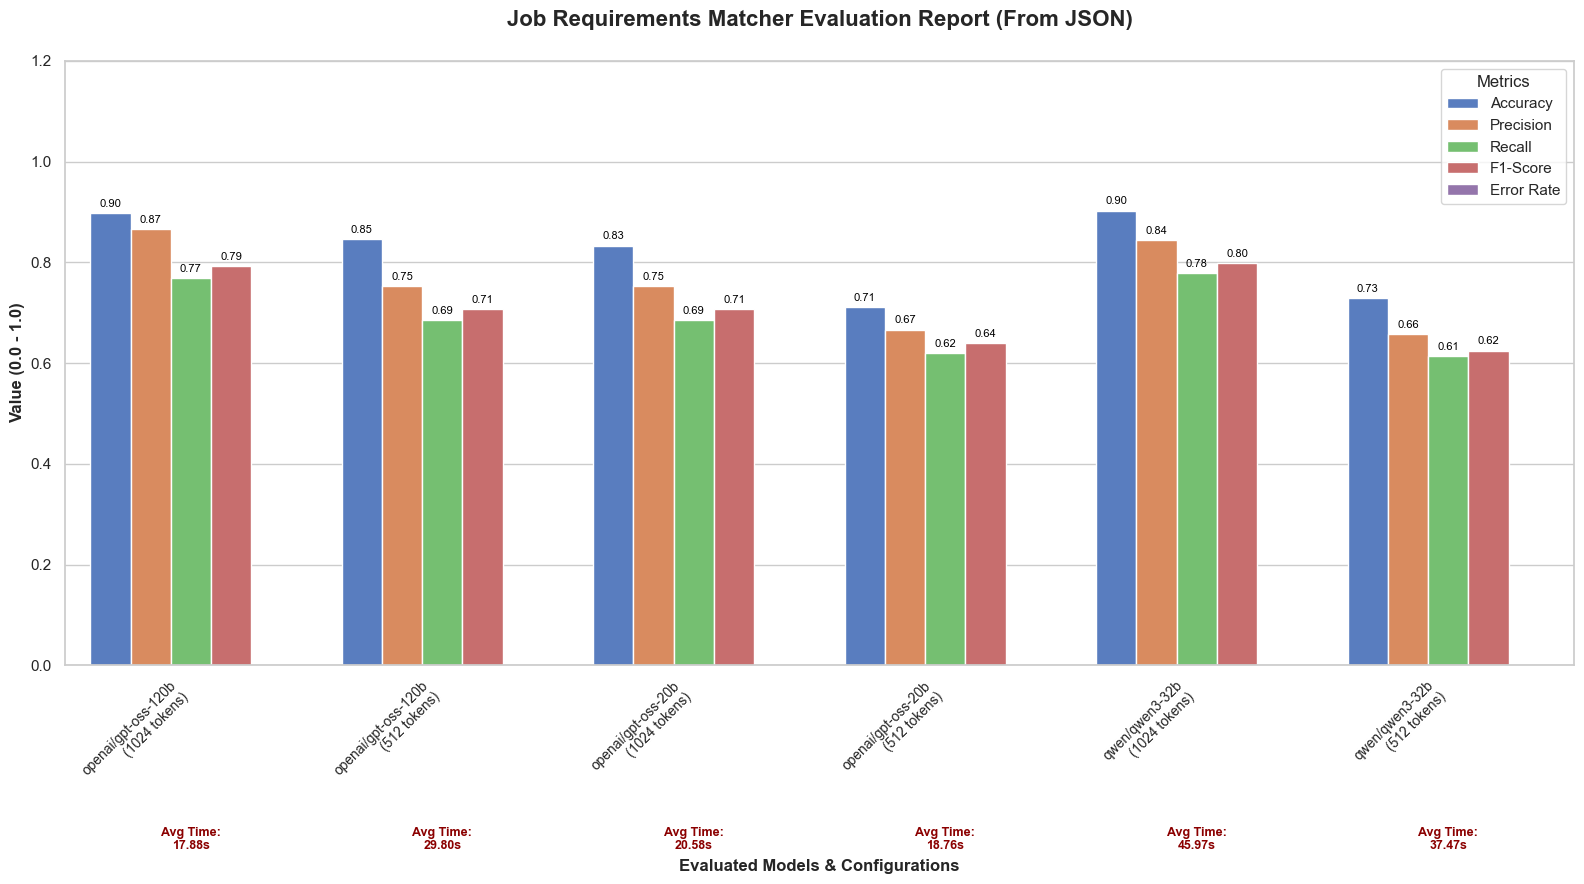

In [4]:
import json
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

JSON_FILE_NAME = "json_results/job_requirements_matcher.json"  

if not os.path.exists(JSON_FILE_NAME):
    parsed_runs = []
    raw_data = [
        {
            "run_id": 1,
            "model_name": "groq:openai/gpt-oss-20b",
            "model_kwargs": {"temperature": 0.0, "max_tokens": 512, "top_p": 0.9},
            "results": {"matcher_accuracy": 0.7111, "matcher_precision": 0.6666, "matcher_recall": 0.62, "matcher_f1_score": 0.6398, "agent_invokation_time": 18.7611, "error_rate": 0.0}
        },
        {
            "run_id": 2,
            "model_name": "groq:openai/gpt-oss-20b",
            "model_kwargs": {"temperature": 0.0, "max_tokens": 1024, "top_p": 0.9},
            "results": {"matcher_accuracy": 0.8333, "matcher_precision": 0.7533, "matcher_recall": 0.6852, "matcher_f1_score": 0.7067, "agent_invokation_time": 20.5798, "error_rate": 0.0}
        },
        {
            "run_id": 3,
            "model_name": "groq:qwen/qwen3-32b",
            "model_kwargs": {"temperature": 0.0, "max_tokens": 512, "top_p": 0.9},
            "results": {"matcher_accuracy": 0.7291, "matcher_precision": 0.6583, "matcher_recall": 0.6138, "matcher_f1_score": 0.625, "agent_invokation_time": 37.4655, "error_rate": 0.0}
        },
        {
            "run_id": 4,
            "model_name": "groq:qwen/qwen3-32b",
            "model_kwargs": {"temperature": 0.0, "max_tokens": 1024, "top_p": 0.9},
            "results": {"matcher_accuracy": 0.9027, "matcher_precision": 0.845, "matcher_recall": 0.7783, "matcher_f1_score": 0.7983, "agent_invokation_time": 45.9702, "error_rate": 0.0}
        },
        {
            "run_id": 5,
            "model_name": "groq:openai/gpt-oss-120b",
            "model_kwargs": {"temperature": 0.0, "max_tokens": 512, "top_p": 0.9},
            "results": {"matcher_accuracy": 0.8458, "matcher_precision": 0.7533, "matcher_recall": 0.6852, "matcher_f1_score": 0.7067, "agent_invokation_time": 29.7986, "error_rate": 0.0}
        },
        {
            "run_id": 6,
            "model_name": "groq:openai/gpt-oss-120b",
            "model_kwargs": {"temperature": 0.0, "max_tokens": 1024, "top_p": 0.9},
            "results": {"matcher_accuracy": 0.8972, "matcher_precision": 0.8666, "matcher_recall": 0.7686, "matcher_f1_score": 0.7921, "agent_invokation_time": 17.8802, "error_rate": 0.0}
        }
    ]
else:
    with open(JSON_FILE_NAME, "r", encoding="utf-8") as f:
        raw_data = json.load(f)

parsed_runs = []
for run in raw_data:
    model_name = run.get("model_name", "Unknown").split(":")[-1] 
    max_tokens = run.get("model_kwargs", {}).get("max_tokens", 0)
    results = run.get("results", {})
    
    model_tag = f"{model_name}\n({max_tokens} tokens)"
    
    parsed_runs.append({
        "Model": model_tag,
        "Accuracy": results.get("matcher_accuracy", 0.0),
        "Precision": results.get("matcher_precision", 0.0),
        "Recall": results.get("matcher_recall", 0.0),
        "F1-Score": results.get("matcher_f1_score", 0.0),
        "Error Rate": results.get("error_rate", 0.0),
        "Time (s)": results.get("agent_invokation_time", 0.0)
    })

df = pd.DataFrame(parsed_runs)

df_grouped = df.groupby("Model", as_index=False).mean()

df_melted = pd.melt(
    df_grouped, 
    id_vars=["Model", "Time (s)"], 
    value_vars=["Accuracy", "Precision", "Recall", "F1-Score", "Error Rate"],
    var_name="Metric", 
    value_name="Score"
)

plt.figure(figsize=(16, 9))
sns.set_theme(style="whitegrid")

ax = sns.barplot(x="Model", y="Score", hue="Metric", data=df_melted, palette="muted")

for p in ax.patches:
    height = p.get_height()
    if height > 0.01:
        ax.annotate(f'{height:.2f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=8, color='black',
                    xytext=(0, 3),
                    textcoords='offset points')

plt.title("Job Requirements Matcher Evaluation Report (From JSON)", fontsize=16, fontweight='bold', pad=25)
plt.ylabel("Value (0.0 - 1.0)", fontsize=12, fontweight='bold')
plt.ylim(0, 1.2) 
plt.legend(title="Metrics", loc="upper right", frameon=True)

plt.xlabel("Evaluated Models & Configurations", fontsize=12, fontweight='bold', labelpad=50)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)

for i, row in df_grouped.iterrows():
    ax.text(i, -0.32, f"Avg Time:\n{row['Time (s)']:.2f}s", 
            ha='center', va='top', fontsize=9, color='darkred', fontweight='bold')

plt.subplots_adjust(bottom=0.28)
plt.tight_layout()

output_image = "requirements_matcher_comparison.png"
plt.savefig(output_image, dpi=300)
plt.show()